# Práctica 3. Aprendizaje computacional con datos de una encuesta sobre COVID

**Asignatura:** Aprendizaje Computacional 1 
**Lenguaje de trabajo:** Python  
**Fichero de entrada:** `DatosEncuestaCOVID_limpio_XX.xlsx`  
**Estudiante:** Miguel Adrian Gheorghe 
**Código del estudiante (XX):** 40

---

## Objetivo general

En esta práctica vas a aplicar **técnicas de regresión** a un subconjunto limpio de 120 filas de una encuesta sobre COVID.
El objetivo no es demostrar causalidad, sino **buscar asociaciones** entre variables de la encuesta y aprender a:

- preparar datos reales para modelar,
- recodificar respuestas textuales,
- construir variables derivadas,
- ajustar varios modelos de regresión,
- interpretar resultados con prudencia.

Trabajarás con variables relacionadas con:

- tabaquismo,
- alcohol,
- bebidas estimulantes,
- antidepresivos,
- tranquilizantes,
- enfermedades metabólicas,
- enfermedades respiratorias,
- síntomas,
- contacto con positivos COVID,
- sospecha de COVID,
- PCR positiva,
- estado de salud autopercibido.

## Cómo leer este cuaderno

Para que no haya dudas, en este notebook aparecen siempre etiquetas muy claras.

### **Debes ejecutar**
La celda ya está preparada.  
Tu tarea es:

1. ejecutarla,
2. comprobar que funciona con tus datos,
3. observar la salida.

### **Debes completar**
La celda tiene una plantilla o un ejemplo parcial.  
Tu tarea es:

1. editar el código,
2. completar lo que falta,
3. ejecutarlo después.

### **Debes ejecutar y revisar**
La celda contiene una propuesta de solución.  
Tu tarea es:

1. ejecutarla,
2. comprobar si esa recodificación o ese análisis tiene sentido,
3. **modificarlo si lo consideras necesario**,
4. justificar cualquier cambio importante.

### **Debes interpretar**
Después de varios bloques aparece una celda de texto.  
Tu tarea es escribir en lenguaje natural:

- qué has hecho,
- qué variables has usado,
- qué resultado has obtenido,
- cómo lo interpretas.

---

## Qué se evalúa

Se evaluará principalmente:

1. la calidad de la preparación de variables,
2. el uso correcto de varios modelos de regresión,
3. la interpretación razonable de los resultados,
4. la claridad del cuaderno entregado.

**No basta con ejecutar código.**  
Debes entender qué estás haciendo y explicarlo.

## Ruta de trabajo

Sigue esta secuencia:

1. **Cargar e inspeccionar** el Excel.
2. **Identificar** las variables relevantes.
3. **Recodificar** las variables necesarias para modelar.
4. Hacer una **descripción mínima** de los datos.
5. Ajustar estos modelos:
   - regresión logística binaria para `sospecha_covid_bin`,
   - regresión logística binaria para `pcr_positiva_bin`,
   - modelo de recuento para `sintomas_n`,
   - regresión logística multinomial para `estado_salud_cat`.
6. Redactar las **conclusiones finales**.

Los bloques opcionales sirven para profundizar, pero no deben impedir completar la práctica básica.

## Paquetes y recordatorios útiles

Si fuese necesario, se podrían instalar así:

```python
# pip install pandas numpy matplotlib scikit-learn statsmodels openpyxl
```

En esta práctica usarás sobre todo:

- `pandas` para cargar y manipular datos,
- `numpy` para operaciones numéricas,
- `matplotlib` para gráficos sencillos,
- `statsmodels` para modelos interpretables,
- `scikit-learn` para un bloque opcional más predictivo.

In [69]:
# Debes ejecutar este bloque

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score
)

# 1. Carga del fichero y primera inspección

## Qué debes hacer en esta sección

- **Debes completar** tu código de estudiante.
- **Debes ejecutar** la carga del Excel.
- **Debes interpretar** qué tipo de fichero estás manejando.

In [70]:
# Debes completar esta parte

# Sustituye XX por tu código de estudiante, por ejemplo "07" o "23"
codigo = "40"

ruta = f"DatosEncuestaCOVID_limpio_{codigo}.xlsx"
df = pd.read_excel(ruta)

print("Ruta utilizada:", ruta)
print("Dimensiones del fichero:", df.shape)
display(df.head())

Ruta utilizada: DatosEncuestaCOVID_limpio_40.xlsx
Dimensiones del fichero: (116, 45)


,cp_antes_clean,sexo_clean,edad_clean,talla_clean,domicilio_antes_clean,profesion_antes_clean,ocio_clean,extranjero_clean,cp_durante_clean,domicilio_durante_clean,...,tiene_comorbilidad,total_sintomas,tiene_sintomas,total_vacunas,tiene_vacuna,peso_clean,imc,edad_grupo,imc_categoria,sintomas_grupo
0,8,1,42,167,2,7,1,0,8,3,...,1,3,1,1,1,72,25,1,1,1
1,19,0,56,167,2,0,0,0,18,2,...,1,0,0,2,1,65,23,2,1,0
2,20,0,33,167,2,6,1,0,19,2,...,1,9,1,0,0,88,31,1,3,3
3,23,0,65,167,2,7,1,0,22,2,...,1,2,1,0,0,58,20,3,1,1
4,23,0,63,167,2,2,1,0,22,2,...,1,1,1,1,1,59,21,3,1,1


In [71]:
# Debes ejecutar este bloque

print("\nPrimeras 30 columnas:")
print(df.columns.tolist()[:30])

print("\nInformación general:")
df.info()


Primeras 30 columnas:
['cp_antes_clean', 'sexo_clean', 'edad_clean', 'talla_clean', 'domicilio_antes_clean', 'profesion_antes_clean', 'ocio_clean', 'extranjero_clean', 'cp_durante_clean', 'domicilio_durante_clean', 'convivientes_durante_clean', 'mascotas_clean', 'seguridad_mes_1_clean', 'fumador_clean', 'alcohol_clean', 'antidepresivos_clean', 'tranquilizantes_clean', 'tratamiento_dolor_clean', 'estado_salud_clean', 'salud_trimestre_clean', 'hospital_ingreso_clean', 'hospital_pruebas_clean', 'patologia_consis_clean', 'patologia_sinasis_clean', 'covid_contacto_clean', 'covid_sospecha_clean', 'covid_pcr_clean', 'covid_anticuerpos_clean', 'transporte_clean', 'seguridad_frecuencia_clean']

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 45 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   cp_antes_clean              116 non-null    int64
 1   sexo_clean         

In [72]:
# Debes ejecutar y revisar este bloque

# Observa un resumen general.
# Si alguna columna parece claramente mal tipada, anótalo para revisarlo más adelante.
display(df.describe(include="all").T.head(20))

,count,mean,std,min,25%,50%,75%,max
cp_antes_clean,116.0,17.181034,6.725163,0.0,14.75,20.0,20.0,29.0
sexo_clean,116.0,0.422414,0.496087,0.0,0.00,0.0,1.0,1.0
edad_clean,116.0,46.146552,13.448940,25.0,35.50,44.5,56.0,81.0
talla_clean,116.0,170.215517,1.864105,167.0,169.00,170.0,172.0,173.0
domicilio_antes_clean,116.0,1.965517,0.631507,0.0,2.00,2.0,2.0,3.0
profesion_antes_clean,116.0,4.767241,3.048471,0.0,2.00,5.0,7.0,10.0
ocio_clean,116.0,0.793103,0.740355,0.0,0.00,1.0,1.0,3.0
extranjero_clean,116.0,0.129310,0.336999,0.0,0.00,0.0,0.0,1.0
cp_durante_clean,116.0,16.474138,6.304534,0.0,14.00,19.0,19.0,28.0
domicilio_durante_clean,116.0,1.844828,0.764466,0.0,1.00,2.0,2.0,3.0


# 2. Localización de las variables relevantes

En el fichero original aparecen nombres abreviados. Si has modificado los nombres de dichas columnas en tu fichero limpio, modifica dichos nombres con Find/Replace (Ctrl+F). Estas son algunas columnas especialmente útiles para esta práctica:

- `2.SEXO_1`
- `3.EDAD_1`
- `4.PESO_1`
- `5TALLA_1`
- `26.FUMADOR_1`
- `27.ALCOHOL_1`
- `28.BEBIDAS_1` a `28.BEBIDAS_6`
- `29.ANTIDEPRESIVOS_1`
- `30.TRANQUILIZANTES_1`
- `33.ESTADO-SALUD_1`
- `34.ENF-METABOLICA_1` a `34.ENF-METABOLICA_8`
- `35.ENF-RESPIRATORIA_1` a `35.ENF-RESPIRATORIA_8`
- `42.SINTOMAS_1` a `42.SINTOMAS_16`
- `48.COVID-CONTACTO_1`
- `49.COVID-SOSPECHA_1`
- `50.COVID-PCR_1`
- `51.COVID-ANTICUERPOS_1` (si tiene datos útiles en tu muestra)

In [73]:
# Debes ejecutar este bloque

columnas_sugeridas = {
    "sexo": "sexo_clean",
    "edad": "edad_clean",
    "peso": "peso_clean",
    "talla": "talla_clean",
    "fumador": "fumador_clean",
    "alcohol": "alcohol_clean",
    "antidepresivos": "antidepresivos_clean",
    "tranquilizantes": "tranquilizantes_clean",
    "estado_salud": "estado_salud_clean",
    "contacto_covid": "covid_contacto_clean",
    "sospecha_covid": "covid_sospecha_clean",
    "pcr": "covid_pcr_clean",
    "anticuerpos": "covid_anticuerpos_clean"
}

for nombre, col in columnas_sugeridas.items():
    print(f"{nombre:18s} ->", "OK" if col in df.columns else "NO ENCONTRADA")

sexo               -> OK
edad               -> OK
peso               -> OK
talla              -> OK
fumador            -> OK
alcohol            -> OK
antidepresivos     -> OK
tranquilizantes    -> OK
estado_salud       -> OK
contacto_covid     -> OK
sospecha_covid     -> OK
pcr                -> OK
anticuerpos        -> OK


In [74]:
# Debes ejecutar y revisar este bloque

# Observa categorías reales en variables clave.
# Si aparecen respuestas abiertas o muy ambiguas, anótalo para comentarlo más tarde.

variables_inspeccion = [
    "sexo_clean", "fumador_clean", "alcohol_clean", "antidepresivos_clean",
    "tranquilizantes_clean", "estado_salud_clean", "covid_contacto_clean",
    "covid_sospecha_clean", "covid_pcr_clean"
]

for col in variables_inspeccion:
    if col in df.columns:
        print("\n" + "=" * 80)
        print(col)
        display(df[col].astype("string").str.strip().value_counts(dropna=False).head(15))


sexo_clean


sexo_clean
0    67
1    49
Name: count, dtype: Int64


fumador_clean


fumador_clean
0    116
Name: count, dtype: Int64


alcohol_clean


...

covid_contacto_clean
0    109
1      7
Name: count, dtype: Int64


covid_sospecha_clean


covid_sospecha_clean
0    99
1    17
Name: count, dtype: Int64


covid_pcr_clean


covid_pcr_clean
0    116
Name: count, dtype: Int64

## Debes interpretar

Describe brevemente qué observas en las variables:

- fumador,
- alcohol,
- antidepresivos,
- tranquilizantes,
- contacto COVID,
- sospecha COVID,
- PCR.

Comenta si hay respuestas abiertas, categorías ambiguas o codificaciones que puedan dificultar la regresión.

> **Respuesta del estudiante:**  
> Escribe aquí tu respuesta.

Variables como fumador, alcohol y pcr no sirven para nada. Todos tienen un valor constante "0" que no aporta información. Estas columnas se podrían eliminar perfectamente.

# 3. Preparación y recodificación de variables

## Meta de esta sección

Debes construir, como mínimo, estas variables derivadas:

- `edad`, `peso_kg`, `talla_cm`, `talla_m`, `imc`
- `sexo`
- `fumador_bin`
- `fumador_intenso_bin`
- `alcohol_bin`
- `alcohol_habitual_bin`
- `estimulantes_bin`
- `antidepresivos_bin`
- `tranquilizantes_bin`
- `benzodiacepinas_bin`
- `tranquilizantes_no_herbales_bin`
- `enf_metabolicas_n`
- `enf_respiratorias_n`
- `sintomas_n`
- `contacto_covid_bin`
- `sospecha_covid_bin`
- `pcr_positiva_bin`
- `estado_salud_cat`

**Importante:** no hace falta que todas las recodificaciones sean perfectas desde el principio.  
Lo importante es que estén bien justificadas y sean útiles para modelar.

In [75]:
# Debes ejecutar este bloque

# Funciones auxiliares reutilizables

def texto_normalizado(serie):
    return (
        serie.astype("string")
            .str.strip()
            .str.lower()
    )

def contiene(serie, patron):
    return texto_normalizado(serie).str.contains(patron, regex=True, na=False)

def recuento_si(columnas):
    total = np.zeros(len(trabajo), dtype=float)
    for col in columnas:
        s = texto_normalizado(trabajo[col])
        total += np.where(s.isin(["si", "sí"]), 1, 0)
    return total

In [76]:
# Debes ejecutar este bloque

# Trabajaremos sobre una copia
trabajo = df.copy()

In [77]:
# Debes ejecutar y revisar este bloque
# Modifica la recodificación si lo consideras necesario

# Conversión de variables numéricas básicas (si está bien limpiada no aparecerán NaN)
trabajo["edad"] = pd.to_numeric(trabajo["edad_clean"], errors="coerce")
trabajo["peso_kg"] = pd.to_numeric(trabajo["peso_clean"], errors="coerce")
trabajo["talla_cm"] = pd.to_numeric(trabajo["talla_clean"], errors="coerce")
trabajo["talla_m"] = trabajo["talla_cm"] / 100

# IMC
trabajo["imc"] = trabajo["peso_kg"] / (trabajo["talla_m"] ** 2)

# Sexo limpio para modelar como categórica
trabajo["sexo"] = (
    trabajo["sexo_clean"]
    .astype("string")
    .str.replace(":", "", regex=False)
    .str.strip()
)

display(trabajo[["sexo_clean", "sexo", "edad", "peso_kg", "talla_cm", "talla_m", "imc"]].head(10))

,sexo_clean,sexo,edad,peso_kg,talla_cm,talla_m,imc
0,1,1,42,72,167,1.67,25.816630
1,0,0,56,65,167,1.67,23.306680
2,0,0,33,88,167,1.67,31.553659
3,0,0,65,58,167,1.67,20.796730
4,0,0,63,59,167,1.67,21.155294
5,0,0,25,63,167,1.67,22.589551
6,0,0,38,73,167,1.67,26.175195
7,0,0,30,58,167,1.67,20.796730
8,1,1,46,74,167,1.67,26.533759
9,1,1,42,86,167,1.67,30.836531


In [78]:
# Debes ejecutar y revisar este bloque
# Modifica la recodificación si lo consideras necesario

# Tabaquismo
s_fumador = texto_normalizado(trabajo["fumador_clean"])

trabajo["fumador_bin"] = np.where(
    s_fumador.eq("0"), 0,
    np.where(s_fumador.notna(), 1, np.nan)
)

trabajo["fumador_intenso_bin"] = np.where(
    contiene(trabajo["fumador_clean"], r"6 a 10|más de 10|mas de 10"),
    1, 0
)

# Alcohol
s_alcohol = texto_normalizado(trabajo["alcohol_clean"])

trabajo["alcohol_bin"] = np.where(
    s_alcohol.eq("0"), 0,
    np.where(s_alcohol.notna(), 1, np.nan)
)

trabajo["alcohol_habitual_bin"] = np.where(
    contiene(trabajo["alcohol_clean"], r"habitual"),
    1, 0
)

display(trabajo[[
    "fumador_clean", "fumador_bin", "fumador_intenso_bin",
    "alcohol_clean", "alcohol_bin", "alcohol_habitual_bin"
]].head(15))

,fumador_clean,fumador_bin,fumador_intenso_bin,alcohol_clean,alcohol_bin,alcohol_habitual_bin
0,0,0.0,0,0,0.0,0
1,0,0.0,0,0,0.0,0
2,0,0.0,0,0,0.0,0
3,0,0.0,0,0,0.0,0
4,0,0.0,0,0,0.0,0
5,0,0.0,0,0,0.0,0
6,0,0.0,0,0,0.0,0
7,0,0.0,0,0,0.0,0
8,0,0.0,0,0,0.0,0
9,0,0.0,0,0,0.0,0


In [79]:
# Debes ejecutar y revisar este bloque
# Modifica la recodificación si lo consideras necesario

# Antidepresivos y tranquilizantes
s_antidep = texto_normalizado(trabajo["antidepresivos_clean"])
trabajo["antidepresivos_bin"] = np.where(
    s_antidep.eq("0"), 0,
    np.where(s_antidep.notna(), 1, np.nan)
)

s_tranq = texto_normalizado(trabajo["tranquilizantes_clean"])
trabajo["tranquilizantes_bin"] = np.where(
    s_tranq.eq("0"), 0,
    np.where(s_tranq.notna(), 1, np.nan)
)

trabajo["benzodiacepinas_bin"] = np.where(
    contiene(
        trabajo["tranquilizantes_clean"],
        r"loraz|alpraz|diazep|bromaz|clonaz|lexatin|orfidal"
    ),
    1, 0
)

trabajo["tranquilizantes_no_herbales_bin"] = np.where(
    contiene(trabajo["tranquilizantes_clean"], r"tila|valeriana|melatonina|infus|marihuana|cannabis"),
    0,
    np.where(trabajo["tranquilizantes_bin"] == 1, 1, 0)
)

display(trabajo[[
    "antidepresivos_clean", "antidepresivos_bin",
    "tranquilizantes_clean", "tranquilizantes_bin",
    "benzodiacepinas_bin", "tranquilizantes_no_herbales_bin"
]].head(15))

,antidepresivos_clean,antidepresivos_bin,tranquilizantes_clean,tranquilizantes_bin,benzodiacepinas_bin,tranquilizantes_no_herbales_bin
0,0,0.0,0,0.0,0,0
1,0,0.0,0,0.0,0,0
2,0,0.0,0,0.0,0,0
3,0,0.0,0,0.0,0,0
4,0,0.0,0,0.0,0,0
5,0,0.0,0,0.0,0,0
6,0,0.0,0,0.0,0,0
7,0,0.0,0,0.0,0,0
8,0,0.0,0,0.0,0,0
9,0,0.0,0,0.0,0,0


In [80]:
# Debes completar esta parte

# Bebidas estimulantes: localiza qué columnas 28.BEBIDAS_* están presentes

# Ahora crea estimulantes_bin con un criterio razonable.
# Sugerencia:
# - cuenta como 1 si en alguna columna aparece algo distinto de "No consumo"
# - cuenta como 0 si en todas las columnas aparece "No consumo" o faltan datos claros
# - justifica tu criterio en la respuesta escrita

# Ejemplo de inicio:
trabajo["estimulantes_bin"] = (trabajo["bebidas_clean"] > 0).astype(int)
display(trabajo["estimulantes_bin"])

0      1
1      1
2      1
3      1
4      1
      ..
111    1
112    1
113    1
114    1
115    1
Name: estimulantes_bin, Length: 116, dtype: int64

In [81]:
# Debes completar esta parte

# Crea:
# - enf_metabolicas_n
# - enf_respiratorias_n
# - sintomas_n
#
# Sugerencia:
# - suma 1 por cada columna con "Si" o "Sí"
# - suma 0 por cada "No"
# - decide cómo tratar "No sé, no me consta" y justifícalo

# Ejemplo de inicio:
trabajo["enf_metabolicas_n"] = trabajo["n_enf_metabolica"]
trabajo["enf_respiratorias_n"] = trabajo["n_enf_respiratoria"]
trabajo["sintomas_n"] = trabajo["total_sintomas"]

display(trabajo["enf_metabolicas_n"], trabajo["enf_respiratorias_n"], trabajo["sintomas_n"])

0      1
1      2
2      1
3      1
4      0
      ..
111    0
112    1
113    1
114    0
115    0
Name: enf_metabolicas_n, Length: 116, dtype: int64

0      1
1      2
2      3
3      3
4      1
      ..
111    0
112    1
113    0
114    1
115    0
Name: enf_respiratorias_n, Length: 116, dtype: int64

0      3
1      0
2      9
3      2
4      1
      ..
111    4
112    7
113    2
114    5
115    1
Name: sintomas_n, Length: 116, dtype: int64

In [82]:
# Debes ejecutar y revisar este bloque
# Modifica la recodificación si lo consideras necesario

# Contacto COVID
s_contacto = texto_normalizado(trabajo["covid_contacto_clean"])
trabajo["contacto_covid_bin"] = np.where(
    s_contacto.isin(["1"]),
    1,
    np.where(s_contacto.eq("0"), 0, np.nan)
)

# Sospecha COVID
s_sospecha = texto_normalizado(trabajo["covid_sospecha_clean"])
trabajo["sospecha_covid_bin"] = np.where(
    s_sospecha.isin(["1"]),
    1,
    np.where(s_sospecha.eq("0"), 0, np.nan)
)

# PCR positiva
s_pcr = texto_normalizado(trabajo["covid_pcr_clean"])
trabajo["pcr_positiva_bin"] = np.where(
    contiene(trabajo["covid_pcr_clean"], r"1"),
    1,
    np.where(contiene(trabajo["covid_pcr_clean"], r"0"), 0, np.nan)
)

display(trabajo[[
    "covid_contacto_clean", "contacto_covid_bin",
    "covid_sospecha_clean", "sospecha_covid_bin",
    "covid_pcr_clean", "pcr_positiva_bin"
]].head(15))

,covid_contacto_clean,contacto_covid_bin,covid_sospecha_clean,sospecha_covid_bin,covid_pcr_clean,pcr_positiva_bin
0,0,0.0,0,0.0,0,0.0
1,0,0.0,0,0.0,0,0.0
2,0,0.0,0,0.0,0,0.0
3,0,0.0,0,0.0,0,0.0
4,0,0.0,0,0.0,0,0.0
5,0,0.0,1,1.0,0,0.0
6,0,0.0,0,0.0,0,0.0
7,0,0.0,0,0.0,0,0.0
8,0,0.0,0,0.0,0,0.0
9,0,0.0,0,0.0,0,0.0


In [83]:
# Debes completar esta parte

# Crea una variable reducida de estado de salud:
# - 0 = Excelente
# - 1 = Bueno
# - 2 = Regular/Malo
#
# Sugerencia:
# - agrupa respuestas abiertas o poco frecuentes como NaN si no encajan bien
# - explica tu criterio

# Ejemplo de inicio:
# s_salud = texto_normalizado(trabajo["33.ESTADO-SALUD_1"])
# trabajo["estado_salud_cat"] = ...

trabajo["estado_salud_cat"] = trabajo["estado_salud_clean"].map({0: 2, 2: 0, 1: 1})
display(trabajo["estado_salud_cat"])

0      0
1      1
2      2
3      2
4      1
      ..
111    1
112    0
113    1
114    1
115    0
Name: estado_salud_cat, Length: 116, dtype: int64

In [84]:
# Debes ejecutar este bloque cuando hayas completado las celdas anteriores

variables_creadas = [
    "sexo", "edad", "peso_kg", "talla_cm", "talla_m", "imc",
    "fumador_bin", "fumador_intenso_bin",
    "alcohol_bin", "alcohol_habitual_bin",
    "estimulantes_bin",
    "antidepresivos_bin", "tranquilizantes_bin",
    "benzodiacepinas_bin", "tranquilizantes_no_herbales_bin",
    "enf_metabolicas_n", "enf_respiratorias_n", "sintomas_n",
    "contacto_covid_bin", "sospecha_covid_bin", "pcr_positiva_bin",
    "estado_salud_cat"
]

existentes = [c for c in variables_creadas if c in trabajo.columns]
faltan = [c for c in variables_creadas if c not in trabajo.columns]

print("Variables creadas correctamente:", existentes)
print("Variables que aún faltan:", faltan)

display(trabajo[existentes].head())

Variables creadas correctamente: ['sexo', 'edad', 'peso_kg', 'talla_cm', 'talla_m', 'imc', 'fumador_bin', 'fumador_intenso_bin', 'alcohol_bin', 'alcohol_habitual_bin', 'estimulantes_bin', 'antidepresivos_bin', 'tranquilizantes_bin', 'benzodiacepinas_bin', 'tranquilizantes_no_herbales_bin', 'enf_metabolicas_n', 'enf_respiratorias_n', 'sintomas_n', 'contacto_covid_bin', 'sospecha_covid_bin', 'pcr_positiva_bin', 'estado_salud_cat']
Variables que aún faltan: []


,sexo,edad,peso_kg,talla_cm,talla_m,imc,fumador_bin,fumador_intenso_bin,alcohol_bin,alcohol_habitual_bin,...,tranquilizantes_bin,benzodiacepinas_bin,tranquilizantes_no_herbales_bin,enf_metabolicas_n,enf_respiratorias_n,sintomas_n,contacto_covid_bin,sospecha_covid_bin,pcr_positiva_bin,estado_salud_cat
0,1,42,72,167,1.67,25.816630,0.0,0,0.0,0,...,0.0,0,0,1,1,3,0.0,0.0,0.0,0
1,0,56,65,167,1.67,23.306680,0.0,0,0.0,0,...,0.0,0,0,2,2,0,0.0,0.0,0.0,1
2,0,33,88,167,1.67,31.553659,0.0,0,0.0,0,...,0.0,0,0,1,3,9,0.0,0.0,0.0,2
3,0,65,58,167,1.67,20.796730,0.0,0,0.0,0,...,0.0,0,0,1,3,2,0.0,0.0,0.0,2
4,0,63,59,167,1.67,21.155294,0.0,0,0.0,0,...,0.0,0,0,0,1,1,0.0,0.0,0.0,1


## Debes interpretar

Explica cómo has recodificado, al menos, estas variables:

- `fumador_bin`,
- `alcohol_bin`,
- `estimulantes_bin`,
- `antidepresivos_bin`,
- `tranquilizantes_bin`,
- `benzodiacepinas_bin`,
- `enf_metabolicas_n`,
- `enf_respiratorias_n`,
- `sintomas_n`,
- `contacto_covid_bin`,
- `sospecha_covid_bin`,
- `pcr_positiva_bin`,
- `estado_salud_cat`.

Si has tomado decisiones discutibles o simplificadoras, justifícalas.

> **Respuesta del estudiante:**  
> Escribe aquí tu respuesta.

Variables como fumador, alcohol, pcr y anticuerpos no sirven para nada. Todos tienen un valor constante "0" que no aporta información. Estas columnas se podrían eliminar perfectamente. Además, las columnas que parten de ellas tampoco nos ayudará con el modelo.

# 4. Comprobaciones previas y análisis descriptivo mínimo

Antes de ajustar modelos debes comprobar que las variables tienen sentido.

In [85]:
# Debes ejecutar este bloque

vars_modelo = [
    "sexo", "edad", "imc", "fumador_bin", "fumador_intenso_bin",
    "alcohol_bin", "alcohol_habitual_bin", "estimulantes_bin",
    "antidepresivos_bin", "tranquilizantes_bin",
    "benzodiacepinas_bin", "tranquilizantes_no_herbales_bin",
    "enf_metabolicas_n", "enf_respiratorias_n", "sintomas_n",
    "contacto_covid_bin", "sospecha_covid_bin",
    "pcr_positiva_bin", "estado_salud_cat"
]

vars_presentes = [c for c in vars_modelo if c in trabajo.columns]

print("Variables presentes para modelado:", vars_presentes)
display(trabajo[vars_presentes].isna().sum().rename("n_missing").to_frame())

Variables presentes para modelado: ['sexo', 'edad', 'imc', 'fumador_bin', 'fumador_intenso_bin', 'alcohol_bin', 'alcohol_habitual_bin', 'estimulantes_bin', 'antidepresivos_bin', 'tranquilizantes_bin', 'benzodiacepinas_bin', 'tranquilizantes_no_herbales_bin', 'enf_metabolicas_n', 'enf_respiratorias_n', 'sintomas_n', 'contacto_covid_bin', 'sospecha_covid_bin', 'pcr_positiva_bin', 'estado_salud_cat']


,n_missing
sexo,0
edad,0
imc,0
fumador_bin,0
fumador_intenso_bin,0
alcohol_bin,0
alcohol_habitual_bin,0
estimulantes_bin,0
antidepresivos_bin,0
tranquilizantes_bin,0


In [86]:
# Debes ejecutar y revisar este bloque

if "fumador_bin" in trabajo.columns and "sospecha_covid_bin" in trabajo.columns:
    print("Tabla cruzada: fumador_bin vs sospecha_covid_bin")
    display(pd.crosstab(trabajo["fumador_bin"], trabajo["sospecha_covid_bin"], dropna=False))

if "alcohol_bin" in trabajo.columns and "sospecha_covid_bin" in trabajo.columns:
    print("Tabla cruzada: alcohol_bin vs sospecha_covid_bin")
    display(pd.crosstab(trabajo["alcohol_bin"], trabajo["sospecha_covid_bin"], dropna=False))

if "contacto_covid_bin" in trabajo.columns and "pcr_positiva_bin" in trabajo.columns:
    print("Tabla cruzada: contacto_covid_bin vs pcr_positiva_bin")
    display(pd.crosstab(trabajo["contacto_covid_bin"], trabajo["pcr_positiva_bin"], dropna=False))

Tabla cruzada: fumador_bin vs sospecha_covid_bin


sospecha_covid_bin,0.0,1.0
fumador_bin,,
0.0,99,17


Tabla cruzada: alcohol_bin vs sospecha_covid_bin


sospecha_covid_bin,0.0,1.0
alcohol_bin,,
0.0,99,17


Tabla cruzada: contacto_covid_bin vs pcr_positiva_bin


pcr_positiva_bin,0.0
contacto_covid_bin,
0.0,109
1.0,7


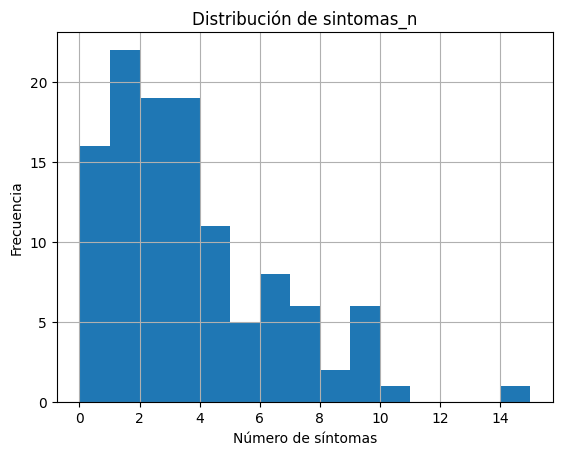

In [87]:
# Debes ejecutar este bloque

if "sintomas_n" in trabajo.columns:
    trabajo["sintomas_n"].hist(bins=15)
    plt.xlabel("Número de síntomas")
    plt.ylabel("Frecuencia")
    plt.title("Distribución de sintomas_n")
    plt.show()

## Debes interpretar

Resume en pocas líneas:

- qué variables tienen más valores perdidos,
- si `sintomas_n` parece estar muy dispersa,
- si observas alguna asociación preliminar interesante en las tablas cruzadas.

> **Respuesta del estudiante:**  
> Escribe aquí tu respuesta.

Analizando primero las tablas, todos son no fumadores, y de todas esas, 99 tienen sospecha de covid y 17 no. Con el alcohol igual. 109 personas no tuvieron contacto y su PCR fue negativa. 7 personas tuvieron contacto pero su PCR siguió siendo negativa. No aparece la columna 1.0 para la PCR. Esto significa que no hay ningún caso positivo confirmado por PCR. 

La variable de sintomas presenta una dispersión asimétrica con sesgo positivo. La gran mayoría de la muestra se concentra en pocos síntomas (de 0 a 4), mientras que solo unos pocos casos aislados llegan a tener entre 9 y 14.

# 5. Modelo 1: regresión logística binaria para sospecha de COVID

## Objetivo

Modelar la variable:

- `sospecha_covid_bin`
  - 1 = sí sospecha haber pasado COVID
  - 0 = no sospecha haberlo pasado

## Idea

Este modelo busca asociaciones entre la sospecha de COVID y variables de hábitos, salud previa y exposición.

In [91]:
# Debes completar esta parte

# Elige las variables que vas a usar en el modelo 1.
# Puedes empezar por esta propuesta y simplificarla si te da problemas por falta de datos.

cols_m1 = [
    "sospecha_covid_bin", "edad", "sexo", "imc", "fumador_bin",
    "alcohol_bin", "estimulantes_bin", "antidepresivos_bin",
    "tranquilizantes_bin", "benzodiacepinas_bin",
    "enf_metabolicas_n", "enf_respiratorias_n",
    "contacto_covid_bin", "sintomas_n"
]

m1 = trabajo[cols_m1].dropna().copy()
print("Dimensiones de m1:", m1.shape)
display(m1)

Dimensiones de m1: (116, 14)


,sospecha_covid_bin,edad,sexo,imc,fumador_bin,alcohol_bin,estimulantes_bin,antidepresivos_bin,tranquilizantes_bin,benzodiacepinas_bin,enf_metabolicas_n,enf_respiratorias_n,contacto_covid_bin,sintomas_n
0,0.0,42,1,25.816630,0.0,0.0,1,0.0,0.0,0,1,1,0.0,3
1,0.0,56,0,23.306680,0.0,0.0,1,0.0,0.0,0,2,2,0.0,0
2,0.0,33,0,31.553659,0.0,0.0,1,0.0,0.0,0,1,3,0.0,9
3,0.0,65,0,20.796730,0.0,0.0,1,0.0,0.0,0,1,3,0.0,2
4,0.0,63,0,21.155294,0.0,0.0,1,0.0,0.0,0,0,1,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,0.0,30,1,30.071168,0.0,0.0,1,0.0,0.0,0,0,0,0.0,4
112,0.0,32,1,23.388687,0.0,0.0,1,0.0,0.0,0,1,1,0.0,7
113,0.0,44,1,27.398176,0.0,0.0,1,0.0,0.0,0,1,0,0.0,2
114,0.0,53,0,19.379197,0.0,0.0,1,0.0,0.0,0,0,1,0.0,5


In [92]:
# Debes ejecutar y revisar este bloque
# Si el modelo falla por falta de casos o por colinealidad, simplifica la fórmula.

formula_m1 = (
    "sospecha_covid_bin ~ edad + C(sexo) + imc + "
    "estimulantes_bin + "
    "antidepresivos_bin + tranquilizantes_bin + "
    "enf_metabolicas_n + "
    "enf_respiratorias_n + contacto_covid_bin + sintomas_n"
)

modelo_logit_1 = smf.logit(formula_m1, data=m1).fit()
print(modelo_logit_1.summary())

Optimization terminated successfully.
         Current function value: 0.260009
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:     sospecha_covid_bin   No. Observations:                  116
Model:                          Logit   Df Residuals:                      105
Method:                           MLE   Df Model:                           10
Date:               lu., 30 mar. 2026   Pseudo R-squ.:                  0.3760
Time:                        18:10:36   Log-Likelihood:                -30.161
converged:                       True   LL-Null:                       -48.335
Covariance Type:            nonrobust   LLR p-value:                 7.334e-05
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -1.3443      3.099     -0.434      0.664      -7.419       4.730
C(

In [93]:
# Debes ejecutar este bloque

odds_ratios_1 = np.exp(modelo_logit_1.params)
display(odds_ratios_1.rename("odds_ratio").to_frame())

,odds_ratio
Intercept,0.260724
C(sexo)[T.1],1.001268
edad,1.014049
imc,0.928818
estimulantes_bin,0.153011
antidepresivos_bin,0.800552
tranquilizantes_bin,1.303191
enf_metabolicas_n,0.580437
enf_respiratorias_n,0.824378
contacto_covid_bin,15.354054


## Debes interpretar

Comenta este modelo. Debes indicar, al menos:

1. qué variables has incluido,
2. cuáles parecen más relevantes,
3. si el signo de los coeficientes tiene sentido,
4. si tabaquismo, alcohol o tranquilizantes muestran asociación,
5. si `contacto_covid_bin` o `sintomas_n` parecen variables importantes.

> **Respuesta del estudiante:**  
> Escribe aquí tu respuesta.

1. Incluimos todas las variables anteriores menos las que son columnas que no aportan información, comentadas anteriormente.
2. Para ver que variables son mas relevantes, hay que ver los valores donde el p-value sea < 0.05. En este caso vemos que sintomas_n nos da un p=0 y contacto_covid_bin=0.016. sintomas_n es la variable más potente del modelo. contacto_covid_bin es un predictor clave y muy significativo. estimulantes_bin esta cerca de la frontera con un valor de 0.064.
3. Los signos de los coeficientes muestran una dirección coherente las variables principales: el contacto previo y el número de síntomas presentan signos positivos significativos, actuando como potentes predictores de la sospecha. Por el contrario, variables como el consumo de estimulantes presentan un signo negativo, lo que sugiere una menor tendencia a la sospecha en este grupo.
4. Tabaquismo y Alcohol: No aparecen en la tabla, al ser variables constantes (nadie fumaba o bebía en la muestra), el modelo las expulsó automáticamente para poder calcularse. No muestran asociación porque no hay variabilidad. Tranquilizantes: No muestra asociación significativa p=0.837. El hecho de tomar o no tranquilizantes no parece influir en si la persona sospecha que tiene COVID o no
5. Son, con diferencia, las dos variables que "mandan" en el modelo. Sus odd_ratio nos dan información que: contacto_covid_bin con un 15.35, significa que haber tenido contacto con un positivo multiplica por 15 las posibilidades de sospechar de COVID en comparación con no haberlo tenido. sintomas_n con un 1.75, por cada síntoma nuevo que añade el paciente, las posibilidades de sospechar del contagio aumentan un 75%

# 6. Modelo 2: regresión logística binaria para PCR positiva

## Objetivo

Modelar:

- `pcr_positiva_bin`
  - 1 = PCR positiva
  - 0 = PCR negativa

**Importante:** aquí solo debes trabajar con personas con resultado claro de PCR.

In [94]:
# Debes completar esta parte

cols_m2 = [
    "pcr_positiva_bin", "edad", "sexo", "imc", "fumador_bin",
    "alcohol_bin", "antidepresivos_bin", "tranquilizantes_bin",
    "enf_metabolicas_n", "enf_respiratorias_n",
    "contacto_covid_bin", "sintomas_n"
]

m2 = trabajo[cols_m2].dropna().copy()
print("Dimensiones de m2:", m2.shape)
display(m2.head())

Dimensiones de m2: (116, 12)


,pcr_positiva_bin,edad,sexo,imc,fumador_bin,alcohol_bin,antidepresivos_bin,tranquilizantes_bin,enf_metabolicas_n,enf_respiratorias_n,contacto_covid_bin,sintomas_n
0,0.0,42,1,25.816630,0.0,0.0,0.0,0.0,1,1,0.0,3
1,0.0,56,0,23.306680,0.0,0.0,0.0,0.0,2,2,0.0,0
2,0.0,33,0,31.553659,0.0,0.0,0.0,0.0,1,3,0.0,9
3,0.0,65,0,20.796730,0.0,0.0,0.0,0.0,1,3,0.0,2
4,0.0,63,0,21.155294,0.0,0.0,0.0,0.0,0,1,0.0,1


In [96]:
# Debes ejecutar y revisar este bloque
# Si lo necesitas, simplifica la fórmula.

formula_m2 = (
    "pcr_positiva_bin ~ edad + C(sexo) + imc + "
    "antidepresivos_bin + "
    "tranquilizantes_bin + enf_metabolicas_n + "
    "enf_respiratorias_n + contacto_covid_bin + sintomas_n"
)

modelo_logit_2 = smf.logit(formula_m2, data=m2).fit()
print(modelo_logit_2.summary())

         Current function value: 0.000000
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:       pcr_positiva_bin   No. Observations:                  116
Model:                          Logit   Df Residuals:                      106
Method:                           MLE   Df Model:                            9
Date:               lu., 30 mar. 2026   Pseudo R-squ.:                     inf
Time:                        19:46:24   Log-Likelihood:            -4.2766e-13
converged:                      False   LL-Null:                        0.0000
Covariance Type:            nonrobust   LLR p-value:                     1.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             -18.9268   2.46e+07  -7.69e-07      1.000   -4.82e+07    4.82e+07
C(sexo)[T.1]            0.2571   4.99e

c:\Users\migue\Desktop\uma-25-26-2\AC1\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\migue\Desktop\uma-25-26-2\AC1\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\migue\Desktop\uma-25-26-2\AC1\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\migue\Desktop\uma-25-26-2\AC1\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified


In [97]:
# Debes ejecutar este bloque

odds_ratios_2 = np.exp(modelo_logit_2.params)
display(odds_ratios_2.rename("odds_ratio").to_frame())

,odds_ratio
Intercept,6.028221e-09
C(sexo)[T.1],1.293222e+00
edad,8.598410e-01
imc,6.691300e-01
antidepresivos_bin,7.447005e-01
tranquilizantes_bin,2.175532e+00
enf_metabolicas_n,1.794562e+00
enf_respiratorias_n,9.680938e-01
contacto_covid_bin,4.793378e-01
sintomas_n,9.401991e-01


## Debes interpretar

Compara este modelo con el anterior y comenta:

- si aparecen los mismos predictores,
- si `sintomas_n` mejora la explicación,
- si `fumador_bin` o `alcohol_bin` siguen teniendo algún papel,
- si el contacto con positivos parece dominante.

> **Respuesta del estudiante:**  
> Escribe aquí tu respuesta.

El modelo de regresión para la variable pcr_positiva_bin no pudo converger debido a la separación perfecta. Esto se debe a que la variable dependiente es constante en la muestra (no existen casos positivos confirmados por PCR), lo que impide al algoritmo encontrar estimadores válidos

# 7. Modelo 3: regresión para recuentos sobre el número de síntomas

## Objetivo

Ahora la variable respuesta será:

- `sintomas_n`

Como es un **recuento**, una estrategia razonable es probar:

1. **Poisson**
2. **Binomial negativa** si observas sobredispersión

In [102]:
# Debes completar esta parte

cols_m3 = [
    "sintomas_n", "edad", "sexo", "imc", "fumador_bin",
    "alcohol_bin", "antidepresivos_bin", "tranquilizantes_bin",
    "benzodiacepinas_bin", "enf_metabolicas_n",
    "enf_respiratorias_n", "contacto_covid_bin"
]

m3 = trabajo[cols_m3].dropna().copy()
print("Dimensiones de m3:", m3.shape)
display(m3.head())

Dimensiones de m3: (116, 12)


,sintomas_n,edad,sexo,imc,fumador_bin,alcohol_bin,antidepresivos_bin,tranquilizantes_bin,benzodiacepinas_bin,enf_metabolicas_n,enf_respiratorias_n,contacto_covid_bin
0,3,42,1,25.816630,0.0,0.0,0.0,0.0,0,1,1,0.0
1,0,56,0,23.306680,0.0,0.0,0.0,0.0,0,2,2,0.0
2,9,33,0,31.553659,0.0,0.0,0.0,0.0,0,1,3,0.0
3,2,65,0,20.796730,0.0,0.0,0.0,0.0,0,1,3,0.0
4,1,63,0,21.155294,0.0,0.0,0.0,0.0,0,0,1,0.0


In [106]:
# Debes ejecutar y revisar este bloque

formula_m3 = (
    "sintomas_n ~ edad + C(sexo) + imc +"
    "antidepresivos_bin + tranquilizantes_bin +"
    "enf_metabolicas_n + enf_respiratorias_n + contacto_covid_bin"
)

modelo_pois = smf.glm(
    formula_m3,
    data=m3,
    family=sm.families.Poisson()
).fit()

print(modelo_pois.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             sintomas_n   No. Observations:                  116
Model:                            GLM   Df Residuals:                      107
Model Family:                 Poisson   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -260.96
Date:               lu., 30 mar. 2026   Deviance:                       225.08
Time:                        19:52:15   Pearson chi2:                     205.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.4000
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               1.6263    

In [107]:
# Debes ejecutar este bloque

sobredisp = modelo_pois.deviance / modelo_pois.df_resid
print("Índice aproximado de sobredispersión:", sobredisp)

Índice aproximado de sobredispersión: 2.103543703746477


In [108]:
# Debes ejecutar y revisar este bloque
# Ejecuta esta celda solo si crees que la sobredispersión es apreciable.

modelo_nb = smf.negativebinomial(formula_m3, data=m3).fit()
print(modelo_nb.summary())

Optimization terminated successfully.
         Current function value: 2.146111
         Iterations: 32
         Function evaluations: 39
         Gradient evaluations: 39
                     NegativeBinomial Regression Results                      
Dep. Variable:             sintomas_n   No. Observations:                  116
Model:               NegativeBinomial   Df Residuals:                      107
Method:                           MLE   Df Model:                            8
Date:               lu., 30 mar. 2026   Pseudo R-squ.:                 0.04692
Time:                        19:52:24   Log-Likelihood:                -248.95
converged:                       True   LL-Null:                       -261.21
Covariance Type:            nonrobust   LLR p-value:                  0.001879
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           

## Debes interpretar

Comenta:

1. si Poisson parece adecuado o no,
2. si hay sobredispersión,
3. qué variables se asocian con un mayor número de síntomas,
4. si las enfermedades respiratorias previas parecen importantes,
5. si fumar, beber alcohol o tomar tranquilizantes aparece relacionado con la carga sintomática.

> **Respuesta del estudiante:**  
> Escribe aquí tu respuesta.

1. Este nuevo modelo (Poisson) es mucho más robusto que el anterior y nos da información muy valiosa sobre qué hace que alguien tenga más o menos síntomas. Al ser una regresión de Poisson, el modelo no predice "sí o no", sino el conteo de síntomas. Hay tres variables con p-value < 0.05: enf_respiratorias_n 0: Es la más potente. Tener patologías respiratorias previas dispara el número de síntomas. edad 0: Curiosamente, aquí tiene un impacto negativo. antidepresivos_bin 0.019: Estar en tratamiento con antidepresivos se asocia con un mayor número de síntomas reportados.
2. En una distribución de Poisson ideal, la media debe ser igual a la varianza (1). Al ser 2.1, significa que tus datos están el doble de "dispersos" de lo que el modelo Poisson puede explicar.
3. Tras detectar sobredispersión en el modelo Poisson, se ha ajustado una Regresión Binomial Negativa. La significación del parámetro alpha p=0.001 valida este cambio. Los resultados finales demuestran que el principal predictor del número de síntomas es la presencia de enfermedades respiratorias previas. Asimismo, se observa que el modelo ha corregido falsos positivos de significación (como el de los antidepresivos), ofreciendo una visión mucho más precisa y conservadora de los datos.

# 8. Modelo 4: regresión logística multinomial para el estado de salud

## Objetivo

Modelar una variable con varias categorías:

- `estado_salud_cat`
  - 0 = Excelente
  - 1 = Bueno
  - 2 = Regular/Malo

Si el tamaño muestral se queda corto, es razonable simplificar el modelo o agrupar mejor algunas categorías.

In [109]:
# Debes completar esta parte

cols_m4 = [
    "estado_salud_cat", "edad", "sexo", "imc", "fumador_bin",
    "alcohol_bin", "antidepresivos_bin", "tranquilizantes_bin",
    "enf_metabolicas_n", "enf_respiratorias_n", "sintomas_n"
]

m4 = trabajo[cols_m4].dropna().copy()
print("Dimensiones de m4:", m4.shape)
display(m4.head())

Dimensiones de m4: (116, 11)


,estado_salud_cat,edad,sexo,imc,fumador_bin,alcohol_bin,antidepresivos_bin,tranquilizantes_bin,enf_metabolicas_n,enf_respiratorias_n,sintomas_n
0,0,42,1,25.816630,0.0,0.0,0.0,0.0,1,1,3
1,1,56,0,23.306680,0.0,0.0,0.0,0.0,2,2,0
2,2,33,0,31.553659,0.0,0.0,0.0,0.0,1,3,9
3,2,65,0,20.796730,0.0,0.0,0.0,0.0,1,3,2
4,1,63,0,21.155294,0.0,0.0,0.0,0.0,0,1,1


In [113]:
# Debes ejecutar y revisar este bloque
# Si el modelo da problemas, simplifica el número de predictores.

formula_m4 = (
    "estado_salud_cat ~ edad + C(sexo) + imc +"
    "tranquilizantes_bin + enf_metabolicas_n + "
    "enf_respiratorias_n + sintomas_n"
)

modelo_multi = smf.mnlogit(formula_m4, data=m4).fit()
print(modelo_multi.summary())

Optimization terminated successfully.
         Current function value: 0.705577
         Iterations 7
                          MNLogit Regression Results                          
Dep. Variable:       estado_salud_cat   No. Observations:                  116
Model:                        MNLogit   Df Residuals:                      100
Method:                           MLE   Df Model:                           14
Date:               lu., 30 mar. 2026   Pseudo R-squ.:                  0.1629
Time:                        20:03:05   Log-Likelihood:                -81.847
converged:                       True   LL-Null:                       -97.777
Covariance Type:            nonrobust   LLR p-value:                  0.004194
 estado_salud_cat=1       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -1.3073      2.076     -0.630      0.529      -5.375       2.761
C(

## Debes interpretar

Comenta qué variables parecen asociarse con peor estado de salud autopercibido.

Reflexiona sobre estas cuestiones:

- ¿tienen más peso los síntomas recientes o las enfermedades previas?
- ¿aparecen tabaquismo, alcohol o medicación psiquiátrica en el modelo?
- ¿qué diferencias observas respecto a los modelos binarios anteriores?

> **Respuesta del estudiante:**  
> Escribe aquí tu respuesta.

1. Para la percepción de "Mala Salud", el historial clínico (enfermedades metabólicas) es el factor dominante ya que tiene un coef de 1.82 y p-value=0.009. sintomas_n tambien tiene un bajo p-value pero el coef es mucho menor.
2. Tabaquismo y alcohol no porque no tenemos datos. Medicación como tranquilizantes no influyen en la salud de la persona.
3. Los modelos binarios anteriores predecían si tenías sospecha de COVID. Allí, lo más importante era el contacto con un positivo. En este modelo, que predice el estado de salud, el contacto con COVID ya no es relevante; lo que importa es la carga de enfermedades crónicas. En el modelo de conteo de síntomas, las enfermedades más importantes eran las respiratorias. En este modelo de estado de salud, las que mandan son las metabólicas. Esto sugiere que las respiratorias te hacen tener más síntomas de COVID, pero las metabólicas son las que te hacen sentir que tu salud general es "Mala".

# 9. Modelo más predictivo con scikit-learn

In [115]:
# Debes completar esta parte

variables_num = [
    "edad", "imc", "enf_metabolicas_n", "enf_respiratorias_n", "sintomas_n"
]
variables_cat = [
    "sexo", "antidepresivos_bin", "tranquilizantes_bin"
]

m5 = trabajo[variables_num + variables_cat + ["sospecha_covid_bin"]].dropna().copy()

X = m5[variables_num + variables_cat]
y = m5["sospecha_covid_bin"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

preproceso = ColumnTransformer([
    ("num", StandardScaler(), variables_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), variables_cat)
])

modelo_l1 = Pipeline([
    ("prep", preproceso),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="saga",
        max_iter=5000
    ))
])

modelo_l1.fit(X_train, y_train)
y_pred = modelo_l1.predict(X_test)
y_prob = modelo_l1.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nInforme de clasificación:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8275862068965517
AUC: 0.87

Matriz de confusión:
[[24  1]
 [ 4  0]]

Informe de clasificación:
              precision    recall  f1-score   support

         0.0       0.86      0.96      0.91        25
         1.0       0.00      0.00      0.00         4

    accuracy                           0.83        29
   macro avg       0.43      0.48      0.45        29
weighted avg       0.74      0.83      0.78        29



c:\Users\migue\Desktop\uma-25-26-2\AC1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\migue\Desktop\uma-25-26-2\AC1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


## Debes interpretar 

Explica brevemente:

- qué diferencia hay entre un modelo más **explicativo** (`statsmodels`) y otro más **predictivo** (`scikit-learn`),
- qué métrica te parece más útil aquí,
- si el modelo predictivo parece razonable con solo 120 filas.

> **Respuesta del estudiante:**  
> Escribe aquí tu respuesta.

1. statsmodels explican la relacion entre variables analizando las mismas entre ellas. sklearn se centra en hacer predicciones y acertar las mismas.
2. El accuracy un valor alto simplemente clasificando a todos los sujetos en la clase mayoritaria (negativos), pero falla totalmente en identificar la clase de interés (positivos). AUC mide la capacidad del modelo para ordenar las observaciones por probabilidad. Un valor de 0.87 indica que el modelo posee un alto poder discriminante; es decir, asigna probabilidades más altas a los casos positivos que a los negativos en el 87% de las comparaciones.
3. No es un modelo predictivo fiable por la falta de "casos positivos reales".

# 10. Interacciones

Probaremos modelos con interacción.

Ejemplos:

- `fumador_bin * enf_respiratorias_n`
- `contacto_covid_bin * sintomas_n`
- `sexo * alcohol_bin`
- `benzodiacepinas_bin * enf_respiratorias_n`

In [117]:
# Debes completar esta parte

formula_inter = (
    "sospecha_covid_bin ~ edad + C(sexo) + imc + "
    "enf_respiratorias_n + contacto_covid_bin * sintomas_n"
)

m_inter = trabajo[[
    "sospecha_covid_bin", "edad", "sexo", "imc",
    "fumador_bin", "enf_respiratorias_n",
    "contacto_covid_bin", "sintomas_n"
]].dropna().copy()

modelo_inter = smf.logit(formula_inter, data=m_inter).fit()
print(modelo_inter.summary())

Optimization terminated successfully.
         Current function value: 0.277726
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:     sospecha_covid_bin   No. Observations:                  116
Model:                          Logit   Df Residuals:                      108
Method:                           MLE   Df Model:                            7
Date:               lu., 30 mar. 2026   Pseudo R-squ.:                  0.3335
Time:                        20:23:43   Log-Likelihood:                -32.216
converged:                       True   LL-Null:                       -48.335
Covariance Type:            nonrobust   LLR p-value:                 3.670e-05
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -0.9881      2.555     -0.387      0.

## Debes interpretar 

¿La interacción probada parece aportar algo?  
¿Tiene sentido desde el punto de vista de la interpretación?

> **Respuesta del estudiante:**  
> Escribe aquí tu respuesta.

Viendo que el p-valor es de 0.8, no es para nada significativo. Realmente ¿Tener síntomas te hace sospechar MÁS si además sabes que estuviste en contacto con un positivo?. Parece tener sentido pero los resultados muestran todo lo contrario. Es mejor usar un modelo con sumas.

# 11. Conclusiones finales obligatorias

Redacta unas conclusiones finales respondiendo, al menos, a estas preguntas:

1. ¿Hay asociación entre tabaquismo y sospecha de COVID?
2. ¿Hay asociación entre tabaquismo y número de síntomas?
3. ¿Hay asociación entre alcohol y alguna variable COVID?
4. ¿Qué ocurre con antidepresivos y tranquilizantes?
5. ¿Influyen las enfermedades metabólicas y respiratorias?
6. ¿Qué variable te parece más importante para explicar PCR positiva o sospecha de COVID?
7. ¿Qué limitaciones tiene trabajar con solo 120 registros y con respuestas autodeclaradas?
8. ¿Qué has aprendido, desde el punto de vista computacional, sobre preparar datos para regresión?

> **Conclusiones del estudiante:**  
> Escribe aquí tus conclusiones finales.

1. Con tabaquismo y alcohol no hay asociaciones porque no tenemos datos y además no lo hemos usado en los modelos.
2. Tranquilizantes: No muestran asociación significativa en ningún modelo. Antidepresivos: En el modelo de Poisson parecían aumentar el número de síntomas, pero al corregir la sobredispersión con la Binomial Negativa, esta relación perdió fuerza.
3. Las enfermedades respiratorias son el predictor clave para el número de síntomas. A más patología respiratoria previa, más cuadro sintomático se reporta. Las enfermedades metabólicas son las que más pesan en la percepción de salud. Son las responsables de que el paciente sienta que su estado general es "Malo", independientemente de los síntomas de COVID.
4. Para Sospecha de COVID: El contacto con un positivo (multiplica el riesgo por 15).
5. Es una muestra muy pequeña. Genera modelos inestables, con errores estándar altos y mucha dificultad para generalizar resultados a la población real. Existe un alto riesgo de sesgo de memoria (el paciente no recuerda bien) y subjetividad.
6. La limpieza de los datos. Columnas con un mismo valor no aportan nada y además provoca fallos. Depende del modelo y objetivo es mejor elegir una forma u otra.

# 12. Entrega

Debes entregar:

1. **Este cuaderno `.ipynb` completo**, con código y respuestas escritas.
2. **El fichero Excel final con las variables derivadas**:  
   `DatosEncuestaCOVID_modelo_XX.xlsx`

---

## Lista de comprobación antes de entregar

- [ ] He puesto mi código de estudiante.
- [ ] He cargado correctamente mi fichero limpio.
- [ ] He inspeccionado las variables relevantes.
- [ ] He creado y revisado las variables derivadas principales.
- [ ] He ajustado los cuatro modelos obligatorios.
- [ ] He escrito las interpretaciones después de cada bloque.
- [ ] He redactado unas conclusiones finales.
- [ ] El cuaderno se entiende y puede ejecutarse.